In [2]:
%reset

Once deleted, variables cannot be recovered. Proceed (y/[n])?  y


In [43]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [ ]:
#TODO: Import household data: Store as two dataframes

# Grab entire excel file and convert to pandas dataframe
# Split into pandas dataframe for demand and pv

# Clean the data: detect any weird metering issues or households

# Grab entire AEMO spot pricing info and convert to dataframe


In [ ]:
class Household:
    
    def __init__(
                self,
                pv_cap,
                df_demand,
                df_pv,
                label=None
    ):
        self.pvCap = pv_cap
        self.dataDemand = df_demand
        self.dataPV = df_pv
        if label != None:
            self.label = label
        else:
            self.label = "no_name"

    def __str__(self):
        return "Type: Household, name: {}".format(self.label)

In [68]:
class CustomerModel:
    """
    Simple VPP Pricing model (vs. Amber complex)
    Based off the origin pricing structure
    """

    def __init__(
                self,
                price_export_24hr,
                price_import_24hr,
                battery_import_24hr=None,
                price_vpp_use=0.0,
                day_charge=0.0,
                bonus_signup=0,
                bonus_monthly=0,
                export_max_yr=None,
                soc_min=0.0,
                price_pv_export_threshold=0.0,
                soc_min_flag=False,
                label=None
    ):
        self.priceExport = price_export_24hr
        self.priceImport = price_import_24hr
        if battery_import_24hr != None:
            self.priceImportBattery = self.priceImport
        else:
            self.priceImportBattery = battery_import_24hr
        self.bonusSignup = bonus_signup
        self.bonusMonthly = bonus_monthly
        self.exportMax = export_max_yr
        self.socMin = soc_min
        self.socMinFlag = soc_min_flag

        if np.shape(self.priceExport)[0] > 1:
            print("This plan has a PV export threshold.")
            self.pvThreshold = price_pv_export_threshold

        self.label="no_name"
        if label != None:
            self.label = label

    def __str__(self):
        return "Type: CustomerModel, Name: {}".format(self.label)



In [86]:
class CustomerModelAmber:

    def __init__(
                    self,
                    label=None
    ):
        self.label="no_name"
        if label != None:
            self.label = label

    def __str__(self):
        print("Type: CustomerModelAmber, Name: {}".format(self.label))

In [70]:
# Put the Origin VPP price structure into a model

"""
Set based on Victoria Origin Go Variable Solar Boost

"""
origin_export_price = np.zeros((24,2))
origin_export_price[:,0] = 0.05 # Flat rate for first 8kWh
origin_export_price[:,1] = 0.01 # Flat rate after 8kWh

origin_import_price = 0.2972*np.ones(24) # Flat rate

origin_vic = CustomerModel(
                    origin_export_price,
                    origin_import_price,
                    price_vpp_use=1.0, # Origin pays $1/kWh for export
                    day_charge=1.2301, # Daily charge
                    bonus_signup=200,
                    export_max_yr=200,
                    soc_min=0.2, # Origin says they will probably leave 20% in the battery
                    soc_min_flag=False, # Origin doesn't let you change the soc min
                    price_pv_export_threshold=8.0,
                    label="Origin Go Variable Solar Boost"
)
print(origin_vic)

This plan has a PV export threshold.
Type: CustomerModel, Name: Origin Go Variable Solar Boost


In [69]:
"""
Set based on Victoria AGL BYOB
With the battery rewards electricity plan treated as FiT income
"""
agl_export_price = 0.015*np.ones((24,1)) # Flat rate
# Set values between 5pm and 9pm
agl_export_price[17:21,:] = 10/40 # Paid $10 for every 40 kWh exported

# Note: Limit is $400 payout per quarter - not coded!!!
agl_import_price = 0.26741*np.ones(24) # Flat rate

agl_vic = CustomerModel(
                    agl_export_price,
                    agl_import_price,
                    price_vpp_use=1.0, # AGL pays $1 for kWh used in a VPP event.
                    day_charge=1.10704, 
                    bonus_signup=200, # Welcome credit is $200
                    export_max_yr=250,
                    bonus_monthly=80/12, # AGL gives annual credit of $80 for VPP participation
                    soc_min=0.2, # AGL says they will probably leave 20% in the battery
                    soc_min_flag=False, # AGL doesn't let you change the soc min
                    label="AGL Bring Your Own Battery"
)
print(agl_vic)

This plan has a PV export threshold.
Type: CustomerModel, Name: AGL Bring Your Own Battery


This plan has a PV export threshold.


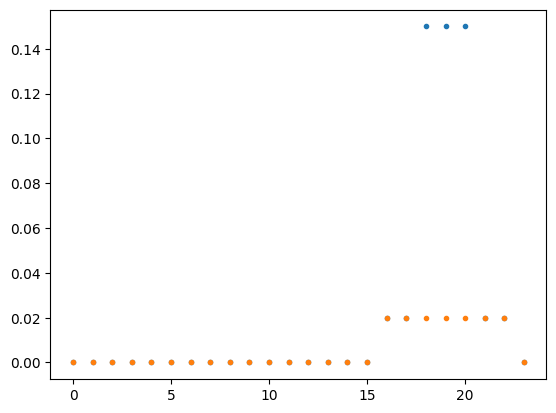

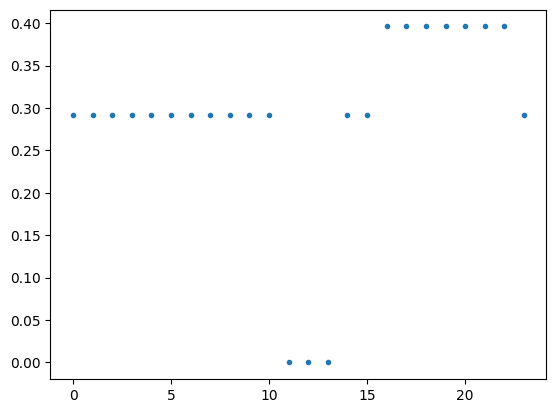

In [84]:
"""
Set based on globird ZEROHERO jemena quote for victoria

    $1 daily bonus for drawing <0.03kWh/hr during 6pm-9pm
    FiT:
    15c for export during 6pm-9pm for first 15kWh
    2c between 4pm-11pm, excluding above
    0c otherwise, excluding above
    $1/kWh FiT during critical peak export event
    
    Consumption:
    0.00c/kWh 11am-2pm
    29.15c/kWh 12am-11am, 2pm-4pm, 11pm-12am
    39.60c/kWh 4pm-11pm
    
    $5c/kWh consumption during critical peak import event
    
    $1.2650/day charge
    
"""
# TODO: Model the daily bonus
# TODO: Model peak import critical event consumption price

globird_export_price = np.zeros((24,2))
# Set price before meeting threshold
globird_export_price[16:23,:] = 0.02
globird_export_price[18:21,0] = 0.15
plt.figure()
plt.plot(np.arange(24), globird_export_price[:,0], '.')
plt.plot(np.arange(24), globird_export_price[:,1], '.')

globird_import_price = np.zeros((24,1))
# Set shoulder prices
globird_import_price[0:11,:] = 0.2915 # 12am-11am
globird_import_price[14:16,:] = 0.2915 #2pm-4pm
globird_import_price[23] = 0.2915 #11pm - 12am
# Set peak prices
globird_import_price[16:23] = 0.3960
plt.figure()
plt.plot(np.arange(24), globird_import_price, '.')

globird_vic = CustomerModel(
                    globird_export_price,
                    globird_import_price,
                    price_vpp_use=1.0, # Globird pays $1 for kWh used in a critical peak export event
                    day_charge=1.2650, 
                    bonus_signup=0, # No welcome credit
                    soc_min=0.0, # No restricitions on minimum battery state of charge, however hardware ususally sets it to 0.2
                    soc_min_flag=False, # Not able to change soc minimmum
                    label="Globird ZEROHERO"
)